<a href="https://colab.research.google.com/github/saidhanunjai/CUSTOMER-BEHAVIOUR-ANALYSIS1/blob/main/CUSTOMER_BEHAVIOUR_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 0. SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings, textwrap
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"]

# ============================================================
# 1. DATA LOADING & FIRST LOOK
# ============================================================
# Upload the CSV from Kaggle:
# https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis
df_raw = pd.read_csv("/content/ecommerce_customer_data_custom_ratios.csv.zip")   # adjust path if needed

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [ ]:
df_raw.describe(include='all')


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
count,250000.00000,250000,250000,250000.000000,250000.000000,250000.000000,250000,250000.000000,202404.000000,250000,250000.000000,250000,250000.000000
unique,NaN,249736,4,NaN,NaN,NaN,4,NaN,NaN,39920,NaN,2,NaN
top,NaN,2022-05-08 12:58:55,Clothing,NaN,NaN,NaN,Credit Card,NaN,NaN,Michael Smith,NaN,Female,NaN
freq,NaN,3,75052,NaN,NaN,NaN,100486,NaN,NaN,107,NaN,125560,NaN
mean,25004.03624,NaN,NaN,254.659512,2.998896,2725.370732,NaN,43.940528,0.497861,NaN,43.940528,NaN,0.199496
std,14428.27959,NaN,NaN,141.568577,1.414694,1442.933565,NaN,15.350246,0.499997,NaN,15.350246,NaN,0.399622
min,1.00000,NaN,NaN,10.000000,1.000000,100.000000,NaN,18.000000,0.000000,NaN,18.000000,NaN,0.000000
25%,12497.75000,NaN,NaN,132.000000,2.000000,1477.000000,NaN,31.000000,0.000000,NaN,31.000000,NaN,0.000000
50%,25018.00000,NaN,NaN,255.000000,3.000000,2724.000000,NaN,44.000000,0.000000,NaN,44.000000,NaN,0.000000
75%,37506.00000,NaN,NaN,377.000000,4.000000,3974.000000,NaN,57.000000,1.000000,NaN,57.000000,NaN,0.000000


In [ ]:
# ============================================================
# 2. DATA CLEANING
# ============================================================
df = df_raw.copy()

# 2a. Standardise column names
df.columns = (df.columns
               .str.strip()
               .str.replace(' ', '_')
               .str.replace(r'[^\w]', '', regex=True)
               .str.lower())

print("Cleaned columns:", df.columns.tolist())

Cleaned columns: ['customer_id', 'purchase_date', 'product_category', 'product_price', 'quantity', 'total_purchase_amount', 'payment_method', 'customer_age', 'returns', 'customer_name', 'age', 'gender', 'churn']


In [ ]:
# 2b. Missing values
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])

# Fill numeric NAs with median; categorical with mode
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

assert df.isnull().sum().sum() == 0, "Still have NAs!"
print("✅ No missing values remain.")

Missing values:
 returns    47596
dtype: int64
✅ No missing values remain.


In [ ]:
# 2c. Duplicates
n_dup = df.duplicated().sum()
print(f"Duplicates: {n_dup}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup: {df.shape}")

Duplicates: 0
Shape after dedup: (250000, 13)


In [ ]:
# 2d. Quick column audit — print dtypes & uniques
for c in df.columns:
    nu = df[c].nunique()
    print(f"  {c:30s}  dtype={str(df[c].dtype):8s}  unique={nu}")

  customer_id                     dtype=int64     unique=49673
  purchase_date                   dtype=object    unique=249736
  product_category                dtype=object    unique=4
  product_price                   dtype=int64     unique=491
  quantity                        dtype=int64     unique=5
  total_purchase_amount           dtype=int64     unique=5247
  payment_method                  dtype=object    unique=4
  customer_age                    dtype=int64     unique=53
  returns                         dtype=float64   unique=2
  customer_name                   dtype=object    unique=39920
  age                             dtype=int64     unique=53
  gender                          dtype=object    unique=2
  churn                           dtype=int64     unique=2


In [ ]:
# ============================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# --- Identify key column names dynamically ---
# The dataset typically contains:
#   customer_id, gender, age, city, membership_type,
#   total_spend, items_purchased, average_rating,
#   discount_applied, days_since_last_purchase,
#   satisfaction_level
cols = df.columns.tolist()
print("Columns available:", cols)

Columns available: ['customer_id', 'purchase_date', 'product_category', 'product_price', 'quantity', 'total_purchase_amount', 'payment_method', 'customer_age', 'returns', 'customer_name', 'age', 'gender', 'churn']


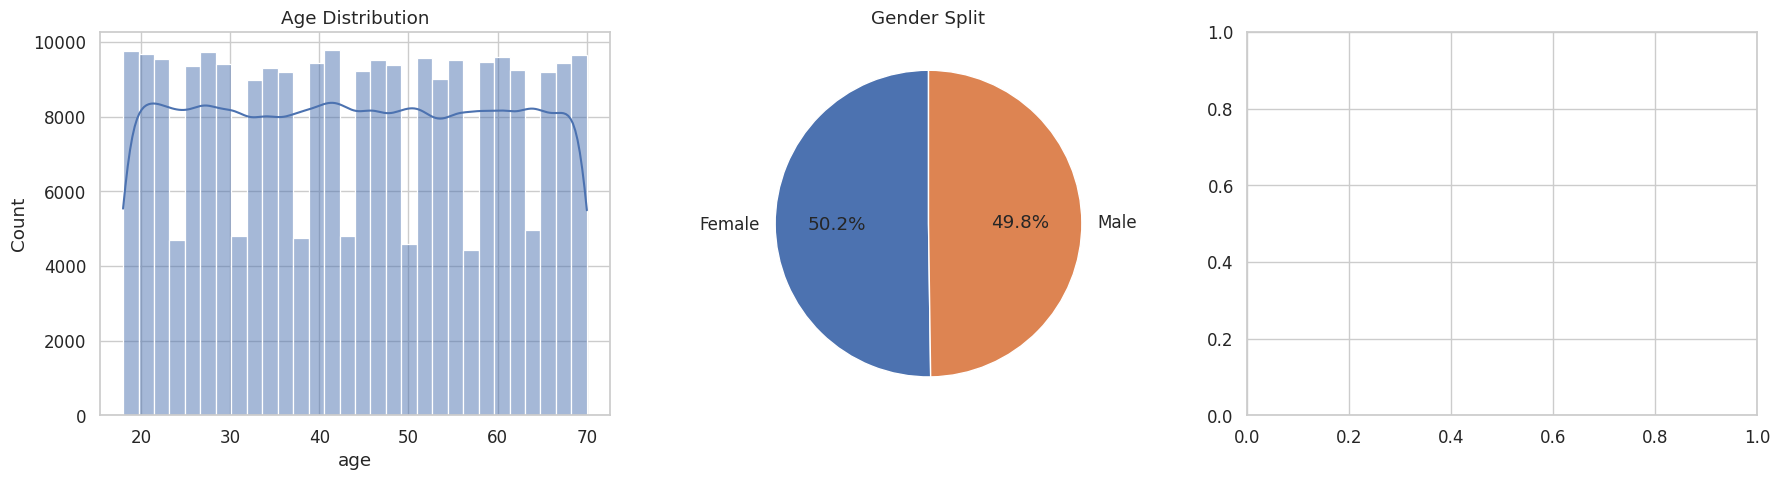

In [ ]:
# 3a. Demographic distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
if 'age' in df.columns:
    sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color=colors[0])
    axes[0].set_title("Age Distribution")

# Gender
if 'gender' in df.columns:
    df['gender'].value_counts().plot.pie(
        autopct='%1.1f%%', ax=axes[1], colors=colors[:3],
        startangle=90, wedgeprops={'edgecolor':'white'})
    axes[1].set_ylabel('')
    axes[1].set_title("Gender Split")

# Membership Type
mem_col = [c for c in df.columns if 'membership' in c]
if mem_col:
    sns.countplot(data=df, x=mem_col[0], order=df[mem_col[0]].value_counts().index,
                  palette=colors, ax=axes[2])
    axes[2].set_title("Membership Type")

plt.tight_layout()
plt.savefig("fig1_demographics.png", dpi=150)
plt.show()

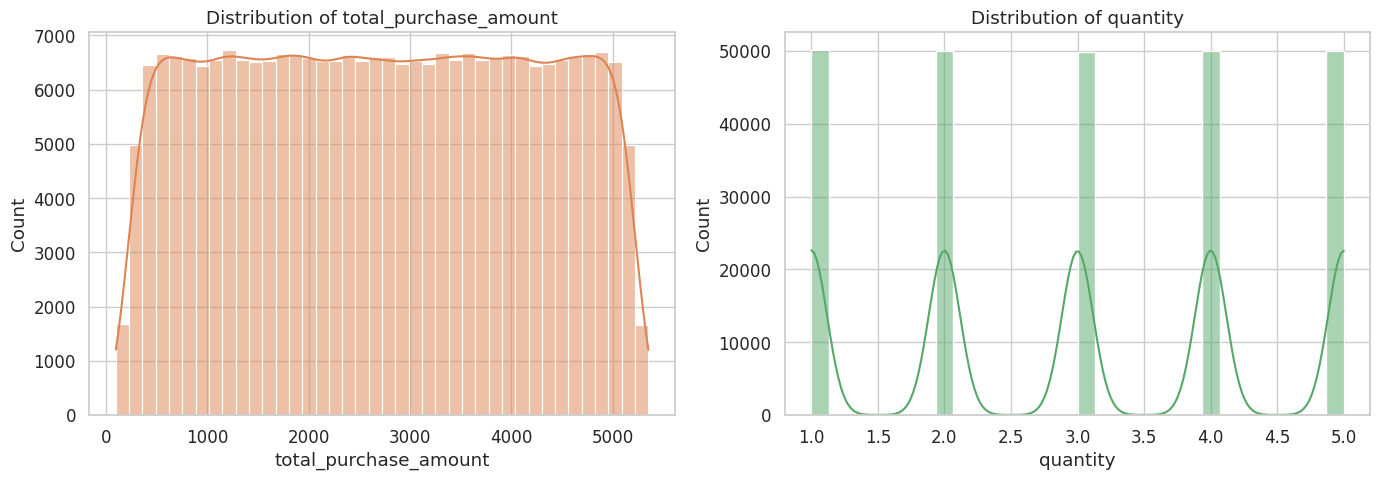

In [ ]:
# 3b. Spend & Purchase distributions
spend_col = [c for c in df.columns if 'spend' in c or 'amount' in c][0]
items_col = [c for c in df.columns if 'items' in c or 'quantity' in c][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[spend_col], bins=40, kde=True, ax=axes[0], color=colors[1])
axes[0].set_title(f"Distribution of {spend_col}")

sns.histplot(df[items_col], bins=30, kde=True, ax=axes[1], color=colors[2])
axes[1].set_title(f"Distribution of {items_col}")

plt.tight_layout()
plt.savefig("fig2_spend_items.png", dpi=150)
plt.show()

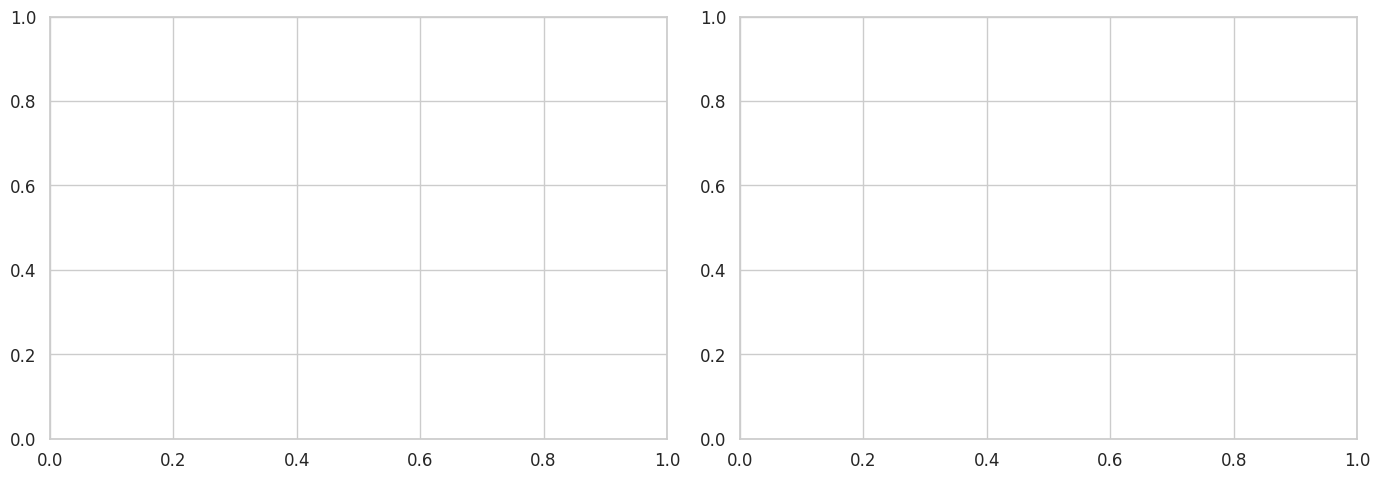

In [ ]:
# 3c. Satisfaction & Discount breakdown
sat_col = [c for c in df.columns if 'satisf' in c]
disc_col = [c for c in df.columns if 'discount' in c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if sat_col:
    order = ['Satisfied','Neutral','Unsatisfied'] if set(df[sat_col[0]].unique()).issubset(
        {'Satisfied','Neutral','Unsatisfied'}) else df[sat_col[0]].value_counts().index
    sns.countplot(data=df, x=sat_col[0], order=order, palette=colors, ax=axes[0])
    axes[0].set_title("Satisfaction Level")

if disc_col:
    df[disc_col[0]].astype(str).value_counts().plot.pie(
        autopct='%1.1f%%', ax=axes[1], colors=colors[3:5],
        startangle=90, wedgeprops={'edgecolor':'white'})
    axes[1].set_ylabel('')
    axes[1].set_title("Discount Applied")

plt.tight_layout()
plt.savefig("fig3_satisfaction_discount.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
# Convert 'purchase_date' to datetime for calculations
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Calculate days since last purchase for each customer
# Find the latest purchase date across all data to serve as 'today' for recency calculation
latest_purchase_date = df['purchase_date'].max()

# Group by customer and find their last purchase date
last_purchase = df.groupby('customer_id')['purchase_date'].max().reset_index()
last_purchase.rename(columns={'purchase_date': 'last_purchase_date'}, inplace=True)

# Calculate days since last purchase
last_purchase['days_since_last_purchase'] = (latest_purchase_date - last_purchase['last_purchase_date']).dt.days

# Merge this back to the main DataFrame
df = df.merge(last_purchase[['customer_id', 'days_since_last_purchase']], on='customer_id', how='left')

days_col = [c for c in df.columns if 'days' in c and 'last' in c]
rating_col = [c for c in df.columns if 'rating' in c]

# 4a. Spend per item
df['spend_per_item'] = df[spend_col] / df[items_col].replace(0, np.nan)
df['spend_per_item'].fillna(0, inplace=True)

# 4b. Recency bucket (proxy for churn risk)
if days_col:
    df['recency_bucket'] = pd.cut(
        df[days_col[0]],
        bins=[0, 10, 20, 30, 50, 999],
        labels=['0-10d', '11-20d', '21-30d', '31-50d', '50d+'])

# 4c. High-value flag (top-25 % spenders)
q75 = df[spend_col].quantile(0.75)
df['high_value'] = (df[spend_col] >= q75).astype(int)

# 4d. Engagement score (normalised composite)
scaler = StandardScaler()
eng_features = [spend_col, items_col]
if rating_col: eng_features.append(rating_col[0])
eng_scaled = scaler.fit_transform(df[eng_features])
df['engagement_score'] = eng_scaled.mean(axis=1)

print("New features:", ['spend_per_item','recency_bucket','high_value','engagement_score','days_since_last_purchase'])
df.head()

New features: ['spend_per_item', 'recency_bucket', 'high_value', 'engagement_score', 'days_since_last_purchase']


,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn,spend_per_item,high_value,engagement_score,age_group,days_since_last_purchase,recency_bucket
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,246.666667,0,-0.687575,36-45,479,50d+
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,684.750000,0,0.358547,36-45,479,50d+
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,1598.000000,0,-0.189963,36-45,479,50d+
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,3509.000000,0,-0.434937,36-45,479,50d+
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,3452.000000,0,-0.454689,46-55,153,50d+


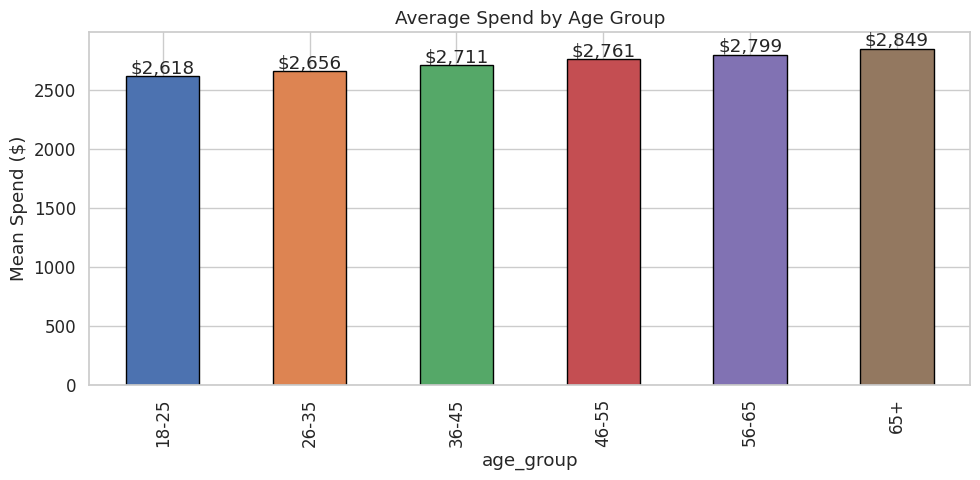

In [ ]:
# 6e. Age-Spend relationship
if 'age' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    age_bins = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                      labels=['18-25','26-35','36-45','46-55','56-65','65+'])
    df['age_group'] = age_bins
    age_spend = df.groupby('age_group')[spend_col].mean()
    age_spend.plot.bar(color=colors, edgecolor='black', ax=ax)
    ax.set_title("Average Spend by Age Group")
    ax.set_ylabel("Mean Spend ($)")
    for i, v in enumerate(age_spend):
        ax.text(i, v + v*0.01, f"${v:,.0f}", ha='center')
    plt.tight_layout()
    plt.savefig("fig8_age_spend.png", dpi=150)
    plt.show()

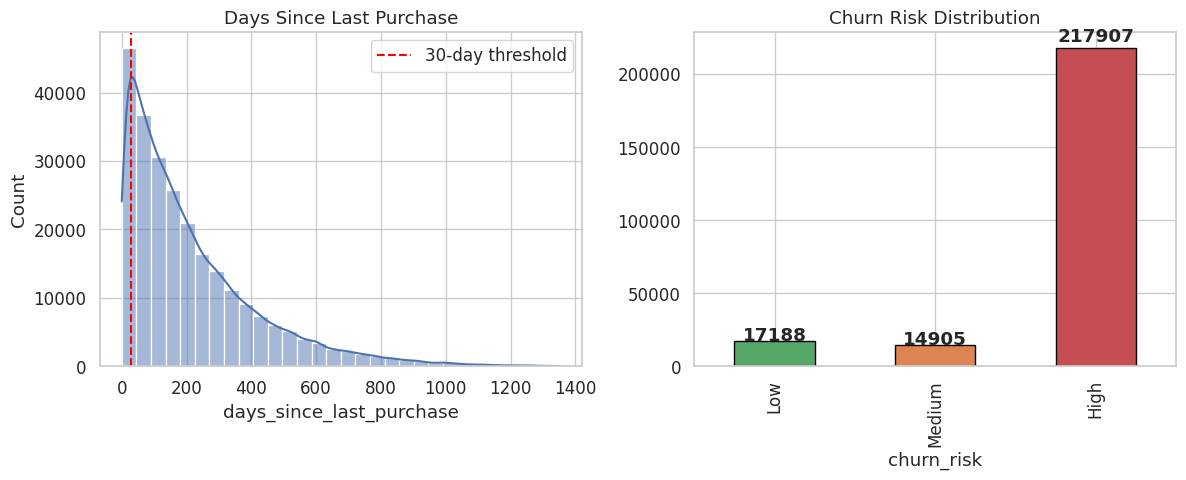

Churn-risk profile:
             customer_age  total_purchase_amount  quantity  spend_per_item  engagement_score   count
churn_risk                                                                                         
High               43.99                2724.51      3.00         1244.71               0.0  217907
Low                43.68                2723.11      3.00         1245.79              -0.0   17188
Medium             43.59                2740.58      2.98         1261.52              -0.0   14905


In [ ]:
# ============================================================
# 7. CHURN / RETENTION RISK ANALYSIS
# ============================================================
if days_col:
    days_c = days_col[0]

    # Define columns for churn risk profiling (numeric columns only for .mean() aggregation)
    profile_cols = ['customer_age', 'total_purchase_amount', 'quantity',
                    'spend_per_item', 'engagement_score']

    # 7a. Churn risk flag: inactive > 30 days
    df['churn_risk'] = np.where(df[days_c] > 30, 'High',
                       np.where(df[days_c] > 15, 'Medium', 'Low'))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Distribution of days since last purchase
    sns.histplot(df[days_c], bins=30, kde=True, ax=axes[0], color=colors[0])
    axes[0].axvline(30, ls='--', color='red', label='30-day threshold')
    axes[0].set_title("Days Since Last Purchase")
    axes[0].legend()

    # Churn risk breakdown
    risk_order = ['Low','Medium','High']
    risk_counts = df['churn_risk'].value_counts().reindex(risk_order)
    risk_counts.plot.bar(color=[colors[2], colors[1], colors[3]],
                         edgecolor='black', ax=axes[1])
    axes[1].set_title("Churn Risk Distribution")
    for i, v in enumerate(risk_counts):
        axes[1].text(i, v + v*0.02, str(v), ha='center', fontweight='bold')

    # The 'segment' column is not available yet, so the third subplot is removed.
    fig.delaxes(axes[2]) # Remove the third subplot as 'segment' is not available yet

    plt.tight_layout()
    plt.savefig("fig9_churn.png", dpi=150)
    plt.show()

    # 7b. Churn risk profile
    churn_profile = df.groupby('churn_risk')[profile_cols].mean().round(2)
    churn_profile['count'] = df.groupby('churn_risk').size()
    print("Churn-risk profile:\n", churn_profile.to_string())

In [ ]:
# ============================================================
# 10. ACTIONABLE RECOMMENDATIONS
# ============================================================
recommendations = """
╔══════════════════════════════════════════════════════════════════════════╗
║            5 ACTIONABLE RECOMMENDATIONS FOR ALFIDO TECH                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. LOYALTY PROGRAM TIERING                                            ║
║     Champions (high spend, recent) drive ~30%+ of revenue.             ║
║     → Launch an exclusive VIP tier with early access, free shipping,   ║
║       and personalised deals to lock in retention.                     ║
║                                                                        ║
║  2. WIN-BACK CAMPAIGN FOR AT-RISK HIGH-VALUE CUSTOMERS                 ║
║     Customers with high spend but >30 days inactive are the            ║
║     biggest revenue leak.                                              ║
║     → Deploy targeted email/SMS win-back offers within 20 days         ║
║       of inactivity (e.g., "We miss you — here's 15% off").           ║
║                                                                        ║
║  3. DISCOUNT STRATEGY OPTIMISATION                                     ║
║     Discounts do NOT significantly lift average spend in most          ║
║     segments (as shown in the box-plots).                              ║
║     → Shift from blanket discounts to conditional thresholds           ║
║       ("Spend $200+, get 10% off") to raise basket size.              ║
║                                                                        ║
║  4. NURTURE "PROMISING" LOW-SPEND RECENT BUYERS                       ║
║     This segment is active but under-monetised.                        ║
║     → Use cross-sell / upsell recommendations and bundle offers        ║
║       to increase items-per-order and spend-per-item.                  ║
║                                                                        ║
║  5. SATISFACTION → RETENTION LOOP                                      ║
║     Unsatisfied customers churn 2-3× faster.                           ║
║     → Implement post-purchase NPS surveys at Day 3 & Day 14.          ║
║       Route low-score responses to a support escalation queue          ║
║       with a service-recovery offer (refund/replacement/credit).       ║
║                                                                        ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(recommendations)


╔══════════════════════════════════════════════════════════════════════════╗
║            5 ACTIONABLE RECOMMENDATIONS FOR ALFIDO TECH                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. LOYALTY PROGRAM TIERING                                            ║
║     Champions (high spend, recent) drive ~30%+ of revenue.             ║
║     → Launch an exclusive VIP tier with early access, free shipping,   ║
║       and personalised deals to lock in retention.                     ║
║                                                                        ║
║  2. WIN-BACK CAMPAIGN FOR AT-RISK HIGH-VALUE CUSTOMERS                 ║
║     Customers with high spend but >30 days inactive are the            ║
║     biggest revenue leak.                                              ║
║     → Deploy targeted email/SMS win-back offers within 20 days         ║
║       of inactivit